# Hyperbolic Equations - Part I

Persamaan hiperbolik merupakan konsep yang cukup umum dan sering muncul dalam berbagai model sistem fisik maupun sistem lain yang menunjukkan karakteristik seperti gelombang. Salah satu bentuk paling sederhana dari persamaan diferensial parsial (PDE) hiperbolik adalah persamaan adveksi:

$$
u_t + a\,u_x = 0
$$

di mana $u(x,t)$ adalah suatu besaran yang berpindah atau terbawa oleh suatu aliran dengan kecepatan $a$. Persamaan ini akan menjadi dasar untuk pembahasan kita pada topik yang lebih luas.

Pada masalah Cauchy (dengan domain spasial tak terbatas), kita hanya membutuhkan kondisi awal $u(x,0) = u_0(x)$. Dari kondisi ini, solusi dari persamaan diferensial parsial sederhana tersebut dapat langsung dituliskan sebagai:

$$
u(x,t) = u_0(x - a t).
$$

Walaupun bentuknya tampak sederhana, persamaan ini tetap memiliki tantangan tersendiri ketika diselesaikan dengan metode numerik. Menariknya, persamaan ini dapat merepresentasikan berbagai kesulitan numerik yang juga ditemui pada PDE hiperbolik yang lebih rumit, meskipun secara analitik sangat mudah untuk diselesaikan.

Jika kita mempertimbangkan persamaan adveksi dengan batas domain yang terbatas, perlu diperhatikan bahwa untuk menjaga konsistensi, kita hanya memerlukan satu kondisi batas, yaitu batas masuk (*in-flow boundary*), dan tidak memerlukan kondisi pada batas keluar (*out-flow boundary*). Penentuan mana yang menjadi batas masuk atau keluar bergantung pada arah aliran, yaitu tanda dari $a$.

Dalam penyelesaian numerik, hal ini dapat menimbulkan masalah tergantung pada metode diskretisasi yang digunakan, misalnya jika diperlukan titik dari batas keluar. Dalam praktiknya, hal ini biasanya diatasi dengan menetapkan kondisi batas numerik yang tidak mengganggu solusi yang keluar, atau dengan menggunakan pendekatan satu sisi (*one-sided approximation*).

Topik ini akan dibahas lebih lanjut nanti, namun penting untuk memahami konsep ini sejak awal.

## First Discretizations
Pendekatan awal yang dapat digunakan adalah mendiskretisasi persamaan ini dengan metode Euler maju (forward Euler) untuk waktu dan beda hingga terpusat orde dua untuk ruang, sehingga diperoleh bentuk diskret:

$$
\frac{U^{n+1}_j - U^n_j}{\Delta t} = \frac{a}{2 \Delta x} (U^n_{j+1} - U^n_{j-1})
$$

atau dapat dituliskan kembali sebagai:

$$
U^{n+1}_j = U^n_j + \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1}).
$$

Namun, metode ini ternyata kurang efektif untuk digunakan dalam praktik. Hal ini akan menjadi lebih jelas ketika kita membahas aspek kestabilan (stability) dari metode tersebut.

Metode lain yang merupakan sedikit modifikasi dari pendekatan sebelumnya dikenal sebagai *metode Lax-Friedrichs*:

$$
U^{n+1}_j = \frac{1}{2}(U^n_{j-1} + U^n_{j+1}) - \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1}).
$$

Pada metode ini, nilai tunggal $U^n_j$ digantikan dengan rata-rata nilai di sekitarnya secara spasial. Meskipun metode ini memiliki sifat kestabilan yang lebih baik (termasuk stabil menurut kriteria Lax-Richtmyer), dalam praktiknya metode ini masih jarang digunakan.

Pendekatan diskretisasi lain yang cukup umum untuk persamaan adveksi adalah metode *Leapfrog* (titik tengah). Dengan metode ini, diperoleh bentuk:

$$
\frac{U^{n+1}_j - U^{n-1}_j}{2 \Delta t} + a \frac{U^n_{j+1} - U^n_{j-1}}{2 \Delta x} = 0
$$

atau jika dituliskan dalam bentuk pembaruan (update):

$$
U^{n+1}_j = U^{n-1}_j - \frac{a \Delta t }{\Delta x} (U^n_{j+1} - U^n_{j-1}).
$$

Metode ini menggunakan pendekatan waktu di titik tengah (melibatkan dua langkah waktu sekaligus), sehingga berbeda dari metode sebelumnya yang hanya bergantung pada satu langkah waktu. Pendekatan ini cukup populer karena memberikan akurasi yang lebih baik dalam beberapa kasus.

Sebelum masuk ke analisis konvergensi, ada satu hal penting terkait hubungan antara $\Delta t$ dan $\Delta x$. Sebagai contoh, pada metode Lax-Friedrichs diperoleh syarat:

$$
\left | \frac{a \Delta t}{\Delta x} \right | \leq 1
$$

Relasi ini (selain dipengaruhi oleh $a$) menunjukkan bahwa $\Delta t$ dan $\Delta x$ dapat berubah dengan orde yang sama. Dari sini dapat disimpulkan bahwa secara umum PDE hiperbolik cenderung kurang kaku (*less stiff*) dibandingkan PDE parabolik, karena perbedaan jenis turunan yang terlibat.

Hal ini juga menjelaskan mengapa PDE hiperbolik dapat diselesaikan secara efektif menggunakan skema waktu eksplisit, berbeda dengan PDE parabolik yang sering kali lebih cocok menggunakan metode implisit.

## Method of Lines Discretization
Sebagai langkah awal untuk memahami kestabilan dari skema diskretisasi yang telah dibahas sebelumnya, kita dapat merumuskan persamaan adveksi menggunakan pendekatan *method of lines*, lalu menganalisis kestabilannya dalam bentuk masalah nilai awal (*initial value problem*).

Untuk dapat menganalisis semua metode yang telah dibahas sebelumnya, kita akan mengasumsikan kondisi batas periodik, sehingga tidak muncul permasalahan batas masuk (*in-flow*) dan batas keluar (*out-flow*). Bentuk kondisi batas tersebut adalah:

$$
u(0, t) = u(1, t), \quad \text{untuk} \ t \geq 0
$$

Di sini, domain yang dipilih adalah $\Omega = [0, 1]$ demi penyederhanaan. Pengaturan ini juga memiliki kemiripan dengan masalah Cauchy yang telah dibahas sebelumnya.

Selanjutnya, kita definisikan sebuah vektor tak diketahui:

$$
U = \begin{bmatrix}
U_1(t) \\ U_2(t) \\ \vdots \\ U_m(t) \\ U_{m+1}(t)
\end{bmatrix}
$$

Di sini, kita menambahkan satu titik ekstra pada $x_{m+1}$ dengan asumsi bahwa $U_0(t) = U_{m+1}(t)$ (karena menggunakan kondisi batas periodik).

Dengan diskretisasi ini, persamaan berubah menjadi sistem persamaan diferensial biasa (ODE) sebagai berikut:

$$
U'_j(t) = -\frac{a}{2 \Delta x}
\begin{cases}
(U_2(t) - U_{m+1}(t)), & j = 1 \\
(U_{j+1}(t) - U_{j-1}(t)), & 2 \leq j \leq m \\
(U_1(t) - U_m(t)), & j = m + 1
\end{cases}
$$

Artinya, perubahan nilai pada setiap titik $j$ terhadap waktu bergantung pada selisih nilai di titik-titik tetangganya. Untuk titik di tengah, digunakan tetangga kiri dan kanan, sedangkan untuk titik di batas digunakan konsep periodik (ujung domain terhubung kembali ke awal).

Dari bentuk sebelumnya, kita dapat menuliskan sistem tersebut sebagai:

$$
U'(t) = A \, U(t)
$$

dengan matriks $A$ didefinisikan sebagai:

$$
A = -\frac{a}{2 \Delta x}
\begin{bmatrix}
0  &  1 &  &  &  & -1 \\
-1 &  0 & 1 \\
   & -1 & 0 & 1 \\
   &  & \ddots & \ddots & \ddots \\
   &  &  & -1 & 0 & 1 \\
1  &  &  &  & -1 & 0 \\
\end{bmatrix}.
$$

Artinya, sistem persamaan diferensial yang kita miliki bisa ditulis dalam bentuk matriks. Matriks $A$ ini menggambarkan hubungan antar titik dalam ruang, yaitu bagaimana setiap titik dipengaruhi oleh tetangganya.

Elemen pada bagian pojok matriks (sudut kiri bawah dan kanan atas) menunjukkan adanya kondisi batas periodik, yaitu titik di ujung domain terhubung kembali ke titik di awal. Pola seperti ini sering muncul pada banyak PDE yang menggunakan kondisi batas periodik.

Matriks $A$ memiliki sifat *skew-symmetric* (antisimetri), yaitu memenuhi $A^T = -A$. Sifat ini menyebabkan nilai eigen (eigenvalues) dari matriks tersebut bersifat imajiner murni.

Nilai eigennya dapat dituliskan sebagai:

$$
\lambda_p = -\frac{i a}{\Delta x} \sin(2 \pi p \Delta x), \quad \text{untuk } p = 1, 2, \ldots , m+1
$$

Sedangkan vektor eigennya adalah:

$$
u^p_j = e^{2 \pi i p j / \Delta x}, \quad \text{untuk } j = 1, 2, \ldots , m + 1.
$$

Secara sederhana, ini berarti solusi dari sistem dapat direpresentasikan sebagai kombinasi gelombang (fungsi eksponensial kompleks). Hal ini sesuai dengan karakter persamaan adveksi yang memang berkaitan erat dengan fenomena gelombang.

Karena semua nilai eigen berada di sepanjang sumbu imajiner,

$$
\lambda \in \left[ -\frac{i a}{\Delta x}, \frac{i a}{\Delta x} \right],
$$

maka dapat disimpulkan bahwa dengan diskretisasi ruang seperti ini, kita memerlukan metode numerik yang memiliki daerah kestabilan absolut (*absolute stability region*) yang mencakup sumbu imajiner.

Jika pengaruh $\Delta t$ juga diperhitungkan, maka diperoleh:

$$
z \in \left[ -\frac{i a \Delta t}{\Delta x}, \frac{i a \Delta t}{\Delta x} \right].
$$

Artinya, metode yang digunakan harus tetap stabil untuk nilai $z$ pada rentang tersebut. Beberapa metode yang memenuhi kriteria ini antara lain metode titik tengah (*midpoint method*) dan beberapa metode Adams. Sementara itu, metode BDF (*Backward Differentiation Formula*) tidak cocok digunakan dalam kasus ini.

### Example:  Forward Euler
Pendekatan pertama yang kita bahas sebelumnya menggunakan metode Euler maju (*forward Euler*) untuk diskretisasi waktu. Jika kita melihat daerah kestabilan absolutnya, diketahui bahwa:

$$
|1 + \Delta t \lambda| \leq 1
$$

Daerah ini berbentuk lingkaran satuan yang berpusat di titik -1 pada bidang kompleks. Dalam kasus ini, perbandingan $\Delta t / \Delta x$ tidak akan menghasilkan metode yang stabil, karena daerah kestabilan tersebut hanya mencakup titik $z = 0$ saja.

Namun, jika $\Delta t$ dibuat mengecil lebih cepat dibandingkan $\Delta x$, maka nilai eigen $\lambda_p$ dari matriks dapat mendekati nol. Dengan kata lain, sistem bisa menjadi lebih stabil karena nilai-nilai tersebut bergerak mendekati pusat daerah kestabilan.

Dalam pembahasan kestabilan Lax-Richtmyer, kita menggunakan batas yang lebih lemah, yaitu $||B|| \leq 1 + \alpha \Delta t$, dengan $B = I + \Delta t A$.

Karena nilai eigen $\lambda_p$ bersifat imajiner murni, dan jika kita memilih $\Delta t = \Delta x^2$, maka diperoleh:

$$
\begin{aligned}
| 1 + \Delta t \lambda_p |^2 &\leq 1 + \left(\frac{a \Delta t}{\Delta x}\right)^2 \\
&\leq 1 + a^2 \Delta x^2 = 1 + a^2 \Delta t.
\end{aligned}
$$

Dari sini, kita bisa membatasi norma matriks $B$ sebagai:

$$
||B|| \leq 1 + \alpha \Delta t
$$

dengan $\alpha = a^2$.

Jika jumlah langkah waktu memenuhi $n \Delta t \leq T$, maka berlaku:

$$
\left\|(I + \Delta t A)^n \right\|_2 \leq (1 + a^2 \Delta t)^{n / 2} \leq e^{a^2 T / 2}
$$

Artinya, pertumbuhan solusi tetap terkontrol (tidak meledak), sehingga metode ini dapat dikatakan stabil menurut kriteria Lax-Richtmyer.

### Example:  Lax-Friedrichs
Akan lebih mudah memahami metode Lax-Friedrichs jika kita menuliskannya kembali. Awalnya diberikan:

$$
U^{n+1}_j = \frac{1}{2}(U^n_{j-1} + U^n_{j+1}) - \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1})
$$

Dengan menggunakan hubungan:

$$
\frac{1}{2}(U^n_{j-1} + U^n_{j+1}) = U^n_j + \frac{1}{2} (U^n_{j-1} - 2 U^n_j + U^n_{j+1}),
$$

persamaan tersebut dapat ditulis ulang menjadi:

$$
U^{n+1}_j = U^n_j + \frac{1}{2} (U^n_{j-1} - 2 U^n_j + U^n_{j+1}) - \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1}).
$$

Bentuk baru ini memperlihatkan bahwa terdapat komponen rata-rata berbobot yang mirip dengan pola beda hingga terpusat orde dua untuk turunan kedua. Dengan kata lain, metode ini secara tidak langsung menambahkan efek seperti difusi ke dalam perhitungan.

Persamaan ini masih bisa disusun ulang sehingga memberikan interpretasi diskret yang lebih jelas:

$$
\frac{U^{n+1}_j - U^n_j}{\Delta t} + a \left(\frac{U^n_{j+1} - U^n_{j-1}}{2 \Delta x} \right ) = \frac{\Delta x^2}{2 \Delta t} \left( \frac{U^n_{j-1} - 2 U^n_j + U^n_{j+1}}{\Delta x^2} \right ).
$$

Bentuk ini menunjukkan bahwa metode Lax-Friedrichs sebenarnya terdiri dari dua bagian utama. Bagian kiri merepresentasikan perubahan terhadap waktu dan efek adveksi (perpindahan), sedangkan bagian kanan menyerupai turunan kedua terhadap ruang, yang berperan seperti difusi.

Dengan kata lain, metode ini tidak hanya memodelkan pergerakan (adveksi), tetapi juga secara tidak langsung menambahkan efek perataan (difusi) ke dalam solusi.

Jika kita memeriksa konsistensi dari pendekatan di sisi kiri, diperoleh:

$$
\begin{aligned}
    &\frac{1}{\Delta t} \left [ u + \Delta t u_t + \frac{\Delta t^2}{2} u_{tt} + \frac{\Delta t^3}{6} u_{ttt} + \mathcal{O}(\Delta t^4) - u \right ] \\
    & \quad + \frac{a}{2 \Delta x}\left [ u + \Delta x u_x + \frac{\Delta x^2}{2} u_{xx} + \frac{\Delta x^3}{6} u_{xxx} - \left( u - \Delta x u_x + \frac{\Delta x^2}{2} u_{xx} - \frac{\Delta x^3}{6} u_{xxx} \right) + \mathcal{O}(\Delta x^4) \right ] \\
    &= u_t + a u_x + \frac{\Delta t}{2} u_{tt} + \frac{\Delta t^2}{6} u_{ttt} + a \frac{\Delta x^2}{6} u_{xxx} + \mathcal{O}(\Delta t^3) + \mathcal{O}(\Delta x^3)
\end{aligned}
$$

Hasil ini menunjukkan bahwa jika hanya melihat sisi kiri saja, maka pendekatan ini sebenarnya sudah konsisten dengan persamaan aslinya (yaitu menghasilkan $u_t + a u_x$ sebagai suku utama).

Namun, muncul beberapa suku tambahan (error terms) yang bergantung pada $\Delta t$ dan $\Delta x$. Inilah yang menyebabkan solusi tidak sepenuhnya ideal, karena ada efek tambahan yang tidak terdapat pada persamaan aslinya.

Jika sisi kanan dikembangkan menggunakan deret Taylor, diperoleh:

$$
\begin{aligned}
\frac{\Delta x^2}{2 \Delta t} \left(u_{xx} + \frac{\Delta x^2}{12} u_{xxxx} + \mathcal{O}(\Delta x^4) \right)
\end{aligned}
$$

Dari hasil ini, dapat disimpulkan bahwa skema tersebut sebenarnya bukan hanya mendiskretisasi persamaan adveksi saja, tetapi juga menyerupai persamaan adveksi-difusi:

$$
u_t + a u_x = \epsilon u_{xx}
$$

dengan nilai koefisien difusi:

$$
\epsilon = \frac{\Delta x^2}{2 \Delta t}.
$$

Artinya, metode ini secara tidak langsung menambahkan efek difusi (perataan) ke dalam solusi. Jadi, selain memodelkan perpindahan (adveksi), metode ini juga menyebabkan solusi menjadi lebih halus karena adanya efek difusi tambahan.

Sistem ini dapat dituliskan kembali dalam bentuk:

$$
U'(t) = A_\epsilon \, U(t)
$$

dengan matriks $A_\epsilon$:

$$
A_\epsilon = -\frac{a}{2 \Delta t}
\begin{bmatrix}
0  &  1 &  &  &  & -1 \\
-1 &  0 & 1 \\
   & -1 & 0 & 1 \\
   &  & \ddots & \ddots & \ddots \\
   &  &  & -1 & 0 & 1 \\
1  &  &  &  & -1 & 0 \\
\end{bmatrix}
+ \frac{\epsilon}{\Delta x^2}
\begin{bmatrix}
-2 & 1 &  &  &  & 1 \\
1  & -2 & 1 \\
   & 1  & -2 & 1 \\
   &  & \ddots & \ddots & \ddots \\
   &  &  & 1 & -2 & 1 \\
1  &  &  &  & 1 & -2
\end{bmatrix}.
$$

Perlu diperhatikan bahwa jika $\epsilon = 0$, maka matriks ini sama seperti matriks $A$ pada metode Euler maju sebelumnya.

Namun, adanya suku tambahan (yang mengandung $\epsilon$) membuat matriks ini tidak lagi bersifat *skew-symmetric*, melainkan menjadi lebih simetris. Akibatnya, nilai eigen tidak lagi murni imajiner.

Suku tambahan ini dapat dipandang sebagai bentuk *regularisasi* atau *relaksasi*, yaitu penambahan efek difusi ke dalam masalah asli. Dengan kata lain, sistem menjadi lebih “halus” dan stabil karena adanya efek perataan.

Hal penting lainnya adalah bahwa dalam praktik, banyak metode numerik untuk persamaan adveksi memang secara alami mengandung efek difusi, baik karena sifat metode tersebut maupun memang sengaja ditambahkan seperti pada kasus ini.

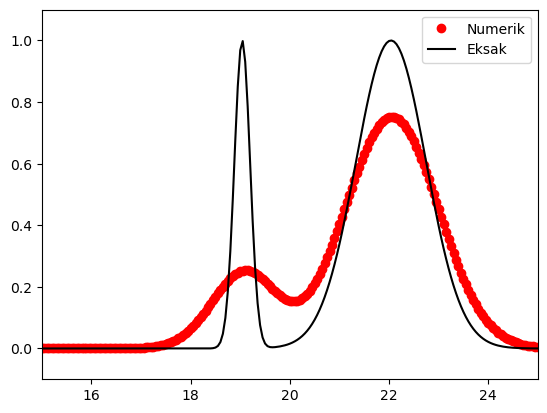

In [4]:
# Import library yang dibutuhkan
import numpy
import matplotlib.pyplot as plt

# Fungsi solusi analitik (true solution)
# Ini digunakan sebagai pembanding hasil numerik
u_true = lambda x, t: numpy.exp(-20.0 * ((x - t) - 2.0)**2) + numpy.exp(-((x - t) - 5.0)**2)

# Jumlah grid (banyak titik ruang)
m = 501

# Membuat domain x dari 0 sampai 25
x = numpy.linspace(0, 25.0, m)

# Menghitung jarak antar grid (Δx)
delta_x = 25.0 / (m - 1)

# CFL number (menentukan kestabilan)
cfl = 0.8

# Menghitung langkah waktu (Δt)
delta_t = cfl * delta_x

# Inisialisasi kondisi awal (t = 0)
U = u_true(x, 0)

# Menyediakan array kosong untuk solusi baru
U_new = numpy.empty(U.shape)

# Waktu awal
t = 0.0

# Waktu akhir simulasi
t_final = 17.0

# Loop waktu (time stepping)
while t < t_final:
    
    # Kondisi batas periodik (titik pertama)
    U_new[0] = 0.5 * (U[1] + U[-1]) - delta_t / (2.0 * delta_x) * (U[1] - U[-1])
    
    # Perhitungan untuk titik tengah (metode Lax-Friedrichs)
    U_new[1:-1] = 0.5 * (U[2:] + U[:-2]) - delta_t / (2.0 * delta_x) * (U[2:] - U[:-2])
    
    # Kondisi batas periodik (titik terakhir)
    U_new[-1] = 0.5 * (U[0] + U[-2]) - delta_t / (2.0 * delta_x) * (U[0] - U[-2])
    
    # Update solusi
    U = U_new.copy()
    
    # Update waktu
    t += delta_t

# ----------------- VISUALISASI -----------------

# Membuat figure
fig = plt.figure()

# Membuat axis
axes = fig.add_subplot(1, 1, 1)

# Plot hasil numerik (titik merah)
axes.plot(x, U, 'ro', label='Numerik')

# Plot solusi eksak (garis hitam)
axes.plot(x, u_true(x, t), 'k', label='Eksak')

# Mengatur batas sumbu x
axes.set_xlim((15.0, 25.0))

# Mengatur batas sumbu y
axes.set_ylim((-0.1, 1.1))

# Menambahkan legenda
axes.legend()

# Menampilkan grafik
plt.show()

<>:77: SyntaxWarning: invalid escape sequence '\e'
<>:77: SyntaxWarning: invalid escape sequence '\e'
C:\Users\x260\AppData\Local\Temp\ipykernel_20740\363808481.py:77: SyntaxWarning: invalid escape sequence '\e'
  axes.set_title("$\epsilon$ = %s, %s" % (epsilon, titles[i]))


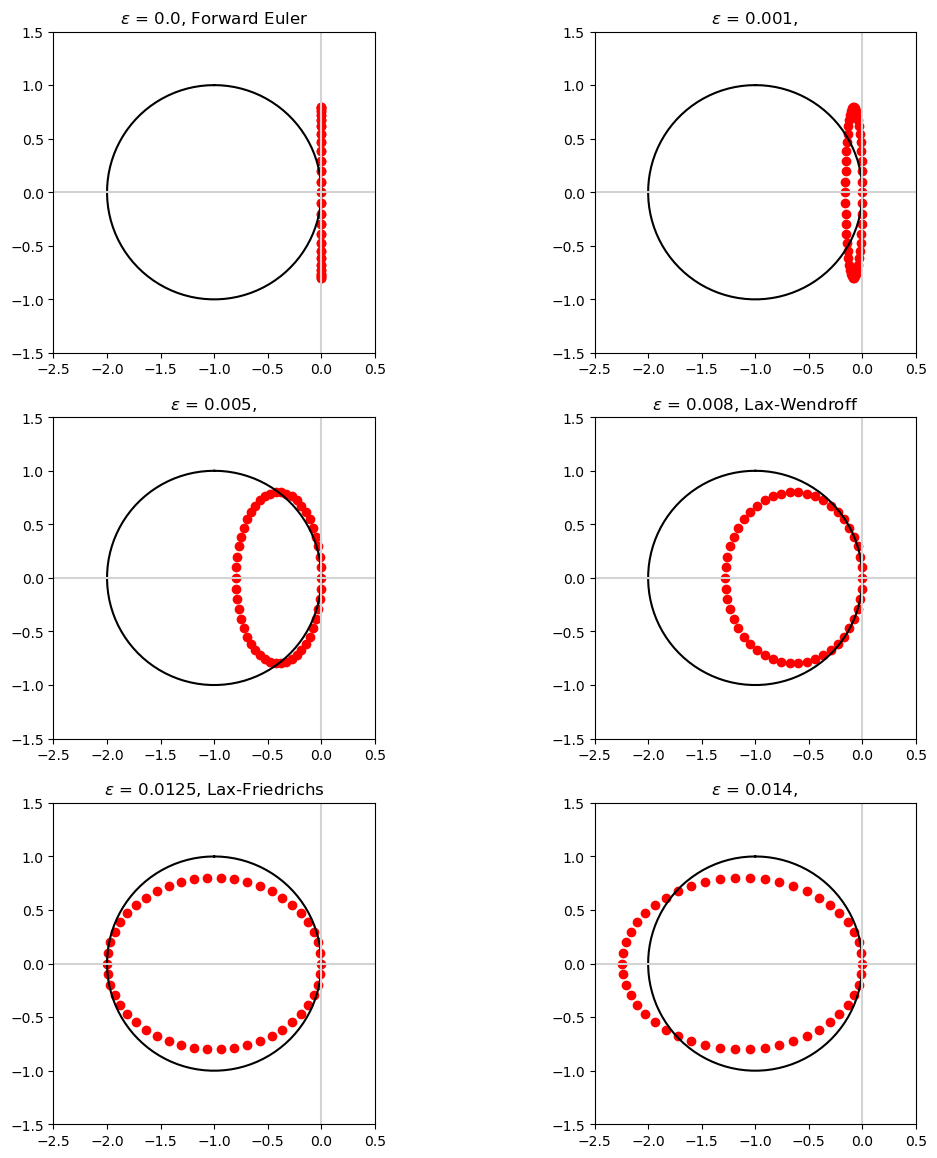

In [1]:
# Import library
import numpy
import matplotlib.pyplot as plt

# Fungsi untuk membangun matriks A_epsilon
def construct_A(epsilon, a=1.0, delta_x=0.02):
    """Membangun matriks A_epsilon dari diskretisasi adveksi-difusi"""
    
    # Membuat vektor berisi 1 (digunakan untuk membangun matriks)
    e = numpy.ones(int(1.0 / delta_x))
    
    # Matriks A (bagian adveksi / turunan pertama)
    # Bentuk beda hingga terpusat
    A = numpy.diag(e[1:], 1) - numpy.diag(e[1:], -1)
    
    # Kondisi batas periodik (pojok matriks)
    A[0, -1] = -1
    A[-1, 0] = 1
    
    # Matriks B (bagian difusi / turunan kedua)
    B = numpy.diag(-2.0 * e, 0) + numpy.diag(e[1:], 1) + numpy.diag(e[1:], -1)
    
    # Kondisi batas periodik
    B[0, -1] = 1
    B[-1, 0] = 1
    
    # Menggabungkan efek adveksi dan difusi
    return -a / (2.0 * delta_x) * A + epsilon / delta_x**2 * B


# Parameter grid
delta_x = 0.02              # ukuran grid ruang (Δx)
delta_t = 0.8 * delta_x    # ukuran langkah waktu (Δt, mengikuti CFL)
a = 1.0                    # kecepatan adveksi

# Membuat figure untuk plot
fig = plt.figure()

# Mengatur ukuran figure agar lebih besar
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 4)

# Judul tiap subplot
titles = ["Forward Euler", "", "", "Lax-Wendroff", "Lax-Friedrichs", ""]

# Loop untuk berbagai nilai epsilon (tingkat difusi)
for (i, epsilon) in enumerate((0.0, 0.001, 0.005, 0.008, 0.0125, 0.014)):
    
    # Membuat subplot
    axes = fig.add_subplot(4, 2, i + 1, aspect='equal')
    
    # ----------------- HITUNG EIGENVALUES -----------------
    
    # Menghitung eigenvalues dari matriks A_epsilon
    eigenvalues = numpy.linalg.eigvals(construct_A(epsilon, a, delta_x))
    
    # Plot eigenvalues (dikalikan Δt agar sesuai stability region)
    axes.plot(delta_t * eigenvalues.real, delta_t * eigenvalues.imag, 'ro')
    
    
    # ----------------- PLOT STABILITY REGION -----------------
    
    # Membuat lingkaran (daerah stabilitas metode Forward Euler)
    theta = numpy.linspace(0.0, 2.0 * numpy.pi, 100)
    
    # Lingkaran berpusat di (-1, 0) dengan radius 1
    axes.plot(numpy.sin(theta) - 1.0, numpy.cos(theta), 'k')
    
    
    # ----------------- PENGATURAN PLOT -----------------
    
    # Batas sumbu x dan y
    axes.set_xlim((-2.5, 0.5))
    axes.set_ylim((-1.5, 1.5))
    
    # Judul subplot (nilai epsilon + nama metode)
    axes.set_title("$\epsilon$ = %s, %s" % (epsilon, titles[i]))
    
    # Garis bantu sumbu (horizontal & vertikal)
    axes.plot([-2.5, 0.5], [0.0, 0.0], color='lightgray')
    axes.plot([0.0, 0.0], [-1.5, 1.5], color='lightgray')


# Menampilkan semua plot
plt.show()

### Example:  Leapfrog
### Contoh: Metode Leapfrog

Untuk metode Leapfrog (midpoint), digunakan persamaan:

$$
U^{n+1}_j = U^{n-1}_j - \frac{a \Delta t}{\Delta x} (U^n_{j+1} - U^n_{j-1})
$$

Diketahui bahwa daerah kestabilannya berada pada interval di sepanjang sumbu imajiner, yaitu $z \in [-i, i]$. Artinya, berdasarkan pendekatan *method of lines*, metode ini akan stabil jika memenuhi syarat:

$$
\left | \frac{a \Delta t}{\Delta x} \right | \leq 1
$$

Namun, ada satu hal penting yang perlu diperhatikan. Nilai $z = \Delta t \lambda_p$ selalu berada tepat di batas daerah kestabilan tersebut. Ini berarti jika ada sedikit gangguan (perturbasi) pada nilai eigen, maka metode bisa menjadi tidak stabil.

Selain itu, metode ini tidak mengalami pertumbuhan maupun peredaman pada setiap mode (disebut *nondissipative*). Hal ini sebenarnya tidak masalah karena persamaan adveksi juga bersifat nondissipatif.

Namun, ada kelemahan lain yaitu munculnya kesalahan dispersi (*dispersive error*), di mana gelombang-gelombang bergerak dengan kecepatan yang berbeda-beda, tidak semuanya sesuai dengan kecepatan sebenarnya $a$. 

Masalah ini bisa menjadi lebih serius jika diterapkan pada sistem yang lebih kompleks, seperti persamaan yang tidak homogen atau bersifat nonlinier.

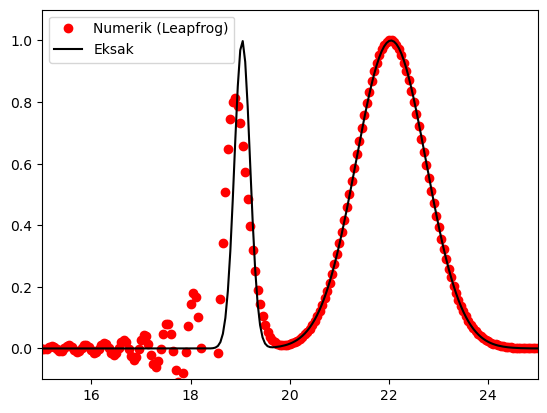

In [2]:
# Import library yang dibutuhkan
import numpy
import matplotlib.pyplot as plt

# Fungsi solusi eksak (true solution) untuk pembanding
u_true = lambda x, t: numpy.exp(-20.0 * ((x - t) - 2.0)**2) + numpy.exp(-((x - t) - 5.0)**2)

# Jumlah grid (banyak titik ruang)
m = 501

# Membuat domain x dari 0 sampai 25
x = numpy.linspace(0, 25.0, m)

# Menghitung jarak antar grid (Δx)
delta_x = 25.0 / (m - 1)

# CFL number (menentukan kestabilan)
cfl = 0.8

# Menghitung langkah waktu (Δt)
delta_t = cfl * delta_x

# Inisialisasi kondisi awal (t = 0)
U = u_true(x, 0)

# Waktu awal
t = 0.0

# Waktu akhir simulasi
t_final = 17.0


# ----------------- START AWAL (JUMP START) -----------------
# Leapfrog butuh dua langkah waktu (n-1 dan n),
# jadi kita pakai Lax-Friedrichs untuk langkah pertama

U_new = numpy.empty(U.shape)

# Boundary kiri (periodik)
U_new[0] = 0.5 * (U[1] + U[-1]) - delta_t / (2.0 * delta_x) * (U[1] - U[-1])

# Titik tengah
U_new[1:-1] = 0.5 * (U[2:] + U[:-2]) - delta_t / (2.0 * delta_x) * (U[2:] - U[:-2])

# Boundary kanan (periodik)
U_new[-1] = 0.5 * (U[0] + U[-2]) - delta_t / (2.0 * delta_x) * (U[0] - U[-2])

# Simpan solusi lama (U^{n-1})
U_old = U_new.copy()

# Update waktu ke langkah berikutnya
t += delta_t


# ----------------- LOOP UTAMA (LEAPFROG) -----------------
while t < t_final:
    
    # Boundary kiri (periodik)
    U_new[0] = U_old[0] - delta_t / delta_x * (U[1] - U[-1])
    
    # Titik tengah (Leapfrog scheme)
    U_new[1:-1] = U_old[1:-1] - delta_t / delta_x * (U[2:] - U[:-2])
    
    # Boundary kanan (periodik)
    U_new[-1] = U_old[-1] - delta_t / delta_x * (U[0] - U[-2])
    
    # Update: geser waktu
    U_old = U.copy()     # U^n jadi U^{n-1}
    U = U_new.copy()     # U^{n+1} jadi U^n
    
    # Update waktu
    t += delta_t


# ----------------- VISUALISASI -----------------

# Membuat figure
fig = plt.figure()

# Membuat axis
axes = fig.add_subplot(1, 1, 1)

# Plot hasil numerik (titik merah)
axes.plot(x, U, 'ro', label='Numerik (Leapfrog)')

# Plot solusi eksak (garis hitam)
axes.plot(x, u_true(x, t), 'k', label='Eksak')

# Batas tampilan x
axes.set_xlim((15.0, 25.0))

# Batas tampilan y
axes.set_ylim((-0.1, 1.1))

# Tambahkan legenda
axes.legend()

# Tampilkan grafik
plt.show()

## The Lax-Wendroff Method
Sejauh ini, satu-satunya metode yang kita gunakan yang memiliki orde dua baik dalam ruang maupun waktu adalah metode Leapfrog. Namun, metode ini memiliki beberapa kelemahan, seperti sifatnya yang tidak memiliki difusi (*nondissipative*) dan juga karena termasuk metode multi-langkah (melibatkan lebih dari satu waktu sebelumnya).

Sekarang, kita akan mencoba pendekatan lain yang masih termasuk metode satu langkah (*one-step method*). Beberapa pilihan yang bisa dipertimbangkan adalah:

1. Menggunakan metode implisit (seperti aturan trapesium / *trapezoidal rule*)
2. Menggunakan metode Runge-Kutta (RK orde 2)
3. Menggunakan pendekatan deret Taylor

Pendekatan-pendekatan ini diharapkan dapat mengatasi beberapa kekurangan dari metode sebelumnya.

1. Menggunakan metode implisit (aturan trapesium)  
   Kita sebenarnya tidak terlalu memerlukan metode implisit, karena persamaan adveksi (dan banyak PDE hiperbolik lainnya) tidak bersifat kaku (*stiff*).

2. Menggunakan metode Runge-Kutta (RK orde 2)  
   Metode ini bisa menjadi cukup rumit, terutama di bagian batas domain. Selain itu, seperti metode Leapfrog, metode ini juga bisa membutuhkan penyimpanan tambahan.

3. Menggunakan metode deret Taylor  
   Pendekatan ini mungkin memerlukan beberapa kali evaluasi diskretisasi ruang, tetapi menghasilkan metode yang dikenal sebagai *metode Lax-Wendroff*.

Cobalah luangkan waktu untuk menurunkan (derive) metode Lax-Wendroff dengan cara mengembangkan turunan waktu menggunakan deret Taylor, lalu menggantinya dengan diskretisasi ruang orde dua menggunakan pendekatan *method of lines*.

1. Menggunakan metode implisit (aturan trapesium)  
   Kita sebenarnya tidak terlalu memerlukan metode implisit, karena persamaan adveksi (dan banyak PDE hiperbolik lainnya) tidak bersifat kaku (*stiff*).

2. Menggunakan metode Runge-Kutta (RK orde 2)  
   Metode ini bisa menjadi cukup rumit, terutama di bagian batas domain. Selain itu, seperti metode Leapfrog, metode ini juga bisa membutuhkan penyimpanan tambahan.

3. Menggunakan metode deret Taylor  
   Pendekatan ini mungkin memerlukan beberapa kali evaluasi diskretisasi ruang, tetapi menghasilkan metode yang dikenal sebagai *metode Lax-Wendroff*.

Cobalah luangkan waktu untuk menurunkan (derive) metode Lax-Wendroff dengan cara mengembangkan turunan waktu menggunakan deret Taylor, lalu menggantinya dengan diskretisasi ruang orde dua menggunakan pendekatan *method of lines*.

Jika dituliskan secara lengkap, diperoleh rumus pembaruan sebagai berikut:

$$
U^{n+1}_j = U^n_j + \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1} ) + \frac{a^2 \Delta t^2}{2 \Delta x^2} (U^n_{j-2} - 2 U^n_{j} + U^n_{j+2}).
$$

Perlu diperhatikan bahwa pola titik (stencil) yang digunakan sekarang menjadi lebih lebar dalam arah ruang. Hal ini disebabkan oleh adanya suku $A^2$, sehingga perhitungan tidak hanya melibatkan tetangga terdekat, tetapi juga titik yang lebih jauh.

Akibatnya, metode ini bisa menimbulkan kesulitan di bagian batas domain, karena membutuhkan lebih banyak titik di sekitar batas untuk melakukan perhitungan.

Jika dituliskan secara lengkap, rumus pembaruannya adalah:

$$
U^{n+1}_j = U^n_j + \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1}) + \frac{a^2 \Delta t^2}{2 \Delta x^2} (U^n_{j-2} - 2U^n_j + U^n_{j+2}).
$$

Dari persamaan ini terlihat bahwa perhitungan tidak hanya melibatkan titik tetangga terdekat ($j-1$ dan $j+1$), tetapi juga titik yang lebih jauh ($j-2$ dan $j+2$). Artinya, stencil (pola titik yang digunakan) menjadi lebih lebar.

Akibatnya, di bagian batas domain bisa muncul masalah, karena kita membutuhkan lebih banyak titik di sekitar batas untuk melakukan perhitungan. Ini membuat implementasinya sedikit lebih rumit dibanding metode yang hanya memakai tetangga terdekat.

Ekspansi yang digunakan adalah deret Taylor terhadap waktu:

$$
u(x, t + \Delta t) = u(x,t) + \Delta t \, u_t(x,t) + \frac{\Delta t^2}{2} u_{tt}(x,t) + \frac{\Delta t^3}{6} u_{ttt}(x,t) + \mathcal{O}(\Delta t^4)
$$

Jika kita mengasumsikan fungsi cukup halus, maka turunan terhadap waktu ($t$) bisa diganti dengan turunan terhadap ruang ($x$) menggunakan persamaan adveksi. Dari sini diperoleh:

$$
u(x, t + \Delta t) = u(x,t) - a \Delta t \, u_x(x,t) + \frac{a^2 \Delta t^2}{2} u_{xx}(x,t) + \frac{a^3 \Delta t^3}{6} u_{xxx}(x,t) + \mathcal{O}(\Delta t^4)
$$

Artinya, perubahan solusi terhadap waktu bisa dinyatakan dalam bentuk turunan ruang. Ini penting karena dalam metode numerik, turunan ruang lebih mudah didiskretisasi dibanding turunan waktu tingkat tinggi.

Dari hasil sebelumnya, kita memperoleh pendekatan metode sebagai berikut:

$$
\begin{aligned}
U^{n+1}_j &= U^n_j - a \Delta t \, D_0 U^n_j + \frac{a^2 \Delta t^2}{2} \, D_2 U^n_j + \frac{a^3 \Delta t^3}{6} u_{xxx}(x,t) + \mathcal{O}(\Delta t^4) \\
&= U^n_j - \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1})  
+ \frac{a^2 \Delta t^2}{2 \Delta x^2} (U^n_{j+1} - 2 U^n_j + U^n_{j-1}) 
+ \frac{a^3 \Delta t^3}{6} u_{xxx}(x,t) + \mathcal{O}(\Delta t^4)
\end{aligned}
$$

Sehingga diperoleh metode akhirnya:

$$
U^{n+1}_j = U^n_j - \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1})  
+ \frac{a^2 \Delta t^2}{2 \Delta x^2} (U^n_{j+1} - 2 U^n_j + U^n_{j-1}).
$$

Dari bentuk ini, terlihat bahwa metode ini hanya menggunakan titik-titik tetangga terdekat (stencil kecil), sehingga lebih sederhana dibanding metode sebelumnya yang membutuhkan titik lebih jauh.

Namun, kesalahan utama yang muncul berasal dari turunan orde tiga terhadap ruang ($u_{xxx}$), yang menyebabkan kesalahan jenis dispersi. Artinya, gelombang dapat merambat dengan kecepatan yang sedikit berbeda dari yang seharusnya.

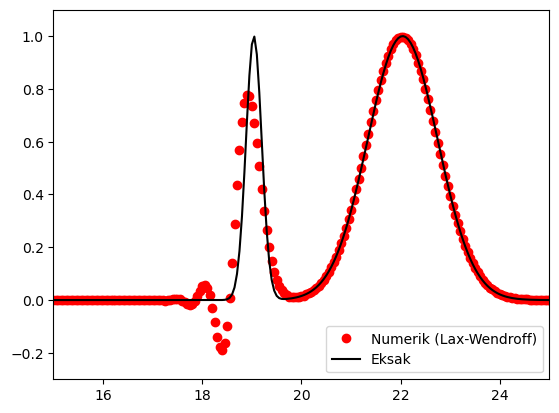

In [1]:
# Import library yang dibutuhkan
import numpy
import matplotlib.pyplot as plt

# Fungsi solusi eksak (true solution)
# Digunakan sebagai pembanding hasil numerik
u_true = lambda x, t: numpy.exp(-20.0 * ((x - t) - 2.0)**2) + numpy.exp(-((x - t) - 5.0)**2)

# Jumlah grid (banyak titik ruang)
m = 501

# Membuat domain ruang dari 0 sampai 25
x = numpy.linspace(0, 25.0, m)

# Menghitung jarak antar grid (Δx)
delta_x = 25.0 / (m - 1)

# CFL number (mengontrol kestabilan)
cfl = 0.8

# Menghitung langkah waktu (Δt)
delta_t = cfl * delta_x

# Inisialisasi kondisi awal pada t = 0
U = u_true(x, 0)

# Menyediakan array untuk solusi di waktu berikutnya
U_new = numpy.empty(U.shape)

# Waktu awal
t = 0.0

# Waktu akhir simulasi
t_final = 17.0


# ----------------- LOOP UTAMA (LAX-WENDROFF) -----------------
while t < t_final:
    
    # Boundary kiri (periodik)
    # Menggunakan titik terakhir sebagai tetangga kiri
    U_new[0] = U[0] \
        - delta_t / (2.0 * delta_x) * (U[1] - U[-1]) \
        + delta_t**2 / (2.0 * delta_x**2) * (U[1] - 2.0 * U[0] + U[-1])
    
    # Titik tengah (Lax-Wendroff scheme)
    U_new[1:-1] = U[1:-1] \
        - delta_t / (2.0 * delta_x) * (U[2:] - U[:-2]) \
        + delta_t**2 / (2.0 * delta_x**2) * (U[2:] - 2.0 * U[1:-1] + U[:-2])
    
    # Boundary kanan (periodik)
    # Menggunakan titik pertama sebagai tetangga kanan
    U_new[-1] = U[-1] \
        - delta_t / (2.0 * delta_x) * (U[0] - U[-2]) \
        + delta_t**2 / (2.0 * delta_x**2) * (U[0] - 2.0 * U[-1] + U[-2])
    
    # Update solusi ke waktu berikutnya
    U = U_new.copy()
    
    # Update waktu
    t += delta_t


# ----------------- VISUALISASI -----------------

# Membuat figure
fig = plt.figure()

# Membuat axis
axes = fig.add_subplot(1, 1, 1)

# Plot hasil numerik (titik merah)
axes.plot(x, U, 'ro', label='Numerik (Lax-Wendroff)')

# Plot solusi eksak (garis hitam)
axes.plot(x, u_true(x, t), 'k', label='Eksak')

# Mengatur batas tampilan sumbu x
axes.set_xlim((15.0, 25.0))

# Mengatur batas tampilan sumbu y
axes.set_ylim((-0.3, 1.1))

# Menambahkan legenda
axes.legend()

# Menampilkan grafik
plt.show()

### Stability
Analisis metode Lax-Wendroff dapat dilakukan dengan cara yang mirip seperti pada metode Lax-Friedrichs, yaitu menggunakan pendekatan matriks umum $A_\epsilon$. Perbedaannya, pada metode ini digunakan nilai $\epsilon = \frac{a^2 \Delta t}{2}$, bukan $\epsilon = \frac{\Delta x^2}{2 \Delta t}$.

Nilai eigen dari matriks $A_\epsilon$ dalam kasus ini adalah:

$$
\Delta t \lambda_p = -i \frac{a \Delta t}{\Delta x} \sin(p \pi \Delta x) + \left( \frac{a \Delta t}{\Delta x} \right)^2 (\cos(p \pi \Delta x) - 1).
$$

Dari contoh numerik sebelumnya, terlihat bahwa nilai-nilai eigen ini berada di dalam daerah kestabilan metode Euler. Selain itu, metode ini juga memiliki syarat kestabilan yang sama dengan metode Lax-Friedrichs.

Hal ini cukup baik, karena metode Lax-Wendroff memiliki akurasi orde dua baik dalam waktu maupun ruang, sedangkan metode Lax-Friedrichs hanya memiliki akurasi orde satu.

<>:82: SyntaxWarning: invalid escape sequence '\e'
<>:82: SyntaxWarning: invalid escape sequence '\e'
C:\Users\x260\AppData\Local\Temp\ipykernel_22816\47089789.py:82: SyntaxWarning: invalid escape sequence '\e'
  axes.set_title("$\epsilon$ = %s, %s" % (epsilon, titles[i]))


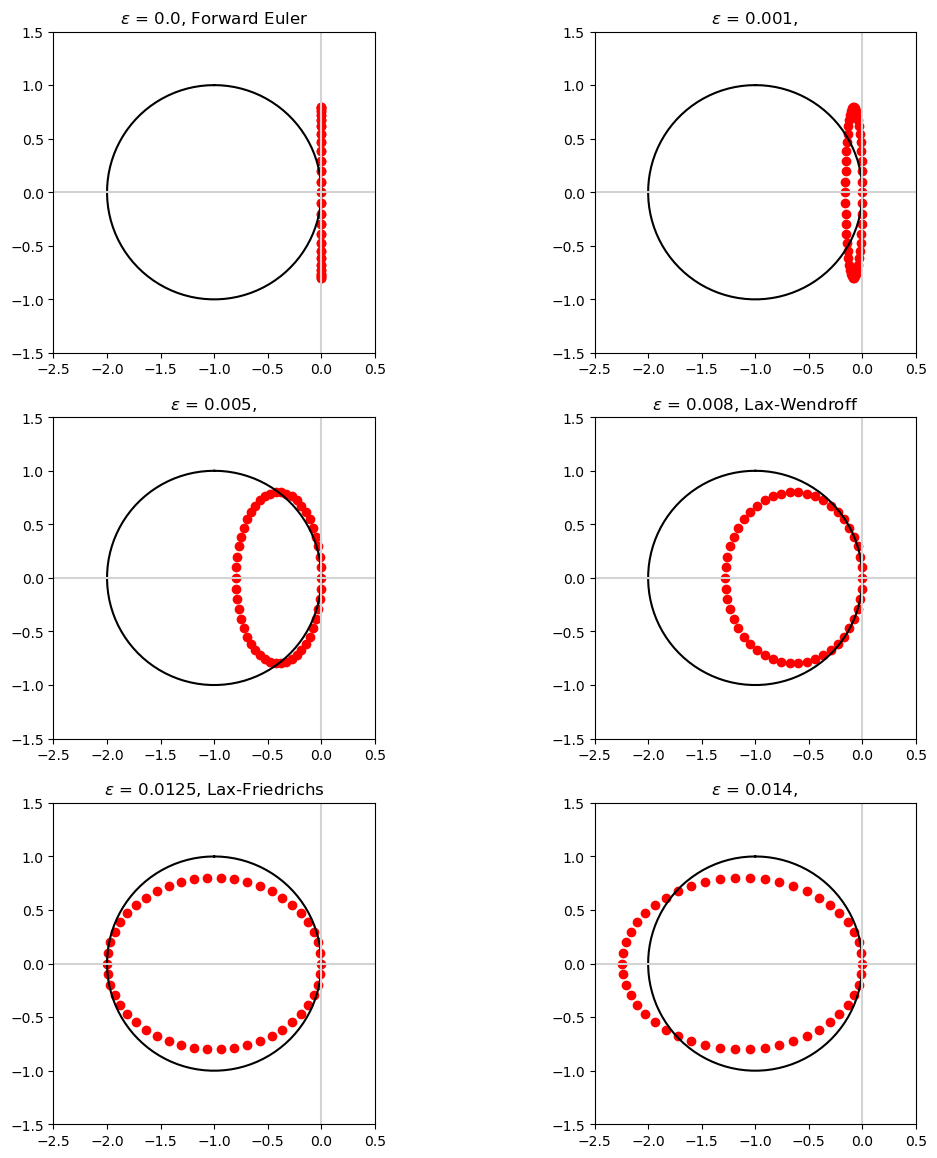

In [1]:
# Import library yang dibutuhkan
import numpy
import matplotlib.pyplot as plt

# Fungsi untuk membangun matriks A_epsilon (adveksi + difusi)
def construct_A(epsilon, a=1.0, delta_x=0.02):
    """Membangun matriks A_epsilon berdasarkan diskretisasi PDE"""
    
    # Membuat vektor berisi angka 1
    e = numpy.ones(int(1.0 / delta_x))
    
    # Matriks A → bagian adveksi (turunan pertama)
    # Menggunakan beda hingga terpusat
    A = numpy.diag(e[1:], 1) - numpy.diag(e[1:], -1)
    
    # Menambahkan kondisi batas periodik (pojok matriks)
    A[0, -1] = -1
    A[-1, 0] = 1
    
    # Matriks B → bagian difusi (turunan kedua)
    B = numpy.diag(-2.0 * e, 0) + numpy.diag(e[1:], 1) + numpy.diag(e[1:], -1)
    
    # Kondisi batas periodik
    B[0, -1] = 1
    B[-1, 0] = 1
    
    # Menggabungkan adveksi dan difusi
    return -a / (2.0 * delta_x) * A + epsilon / delta_x**2 * B


# ----------------- PARAMETER -----------------

delta_x = 0.02              # ukuran grid ruang (Δx)
delta_t = 0.8 * delta_x    # ukuran langkah waktu (Δt)
a = 1.0                    # kecepatan adveksi

# Membuat figure untuk plotting
fig = plt.figure()

# Mengatur ukuran figure agar lebih besar
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 4)

# Judul untuk masing-masing subplot
titles = ["Forward Euler", "", "", "Lax-Wendroff", "Lax-Friedrichs", ""]


# ----------------- LOOP BERBAGAI EPSILON -----------------

# epsilon mengontrol besar efek difusi
for (i, epsilon) in enumerate((0.0, 0.001, 0.005, 0.008, 0.0125, 0.014)):
    
    # Membuat subplot
    axes = fig.add_subplot(4, 2, i + 1, aspect='equal')
    
    # -------- HITUNG & PLOT EIGENVALUES --------
    
    # Menghitung eigenvalues dari matriks A_epsilon
    eigenvalues = numpy.linalg.eigvals(construct_A(epsilon, a, delta_x))
    
    # Plot eigenvalues (dikalikan Δt untuk analisis stabilitas)
    axes.plot(delta_t * eigenvalues.real, delta_t * eigenvalues.imag, 'ro')
    
    
    # -------- PLOT DAERAH STABILITAS --------
    
    # Membuat sudut untuk lingkaran
    theta = numpy.linspace(0.0, 2.0 * numpy.pi, 100)
    
    # Plot lingkaran stabilitas metode Forward Euler
    # (pusat di -1, radius 1)
    axes.plot(numpy.sin(theta) - 1.0, numpy.cos(theta), 'k')
    
    
    # -------- PENGATURAN TAMPILAN --------
    
    # Batas sumbu x dan y
    axes.set_xlim((-2.5, 0.5))
    axes.set_ylim((-1.5, 1.5))
    
    # Judul subplot (nilai epsilon + jenis metode)
    axes.set_title("$\epsilon$ = %s, %s" % (epsilon, titles[i]))
    
    # Garis bantu sumbu horizontal dan vertikal
    axes.plot([-2.5, 0.5], [0.0, 0.0], color='lightgray')
    axes.plot([0.0, 0.0], [-1.5, 1.5], color='lightgray')


# Menampilkan semua plot
plt.show()

## Upwind Methods
Salah satu hal dari persamaan adveksi sederhana yang belum dimanfaatkan adalah sifat asimetrisnya, yang dipengaruhi oleh nilai $a$. 

Jika $a > 0$, maka gelombang akan bergerak ke arah kanan. Sebaliknya, jika $a < 0$, gelombang akan bergerak ke arah kiri.

Hal ini menunjukkan bahwa kita mungkin tidak perlu selalu menggunakan pendekatan beda hingga terpusat (centered difference). Sebagai gantinya, kita bisa menggunakan beda hingga satu arah (one-sided difference) yang menyesuaikan dengan arah pergerakan gelombang.

Pertimbangkan pendekatan beda hingga satu arah berikut:

$$
u_x(x_j, t) \approx \frac{1}{\Delta x} (U_j - U_{j-1}) \quad \text{dan} \quad u_x(x_j, t) \approx \frac{1}{\Delta x} (U_{j+1} - U_j)
$$

Kedua pendekatan ini merupakan aproksimasi turunan pertama dengan akurasi orde satu.

Jika dikombinasikan dengan metode Euler maju untuk waktu, maka diperoleh:

$$
U^{n+1}_j = U^n_j - \frac{a \Delta t}{\Delta x} (U^n_j - U^n_{j-1})
$$

atau

$$
U^{n+1}_j = U^n_j - \frac{a \Delta t}{\Delta x} (U^n_{j+1} - U^n_j)
$$

Metode-metode ini memiliki akurasi orde satu, baik dalam waktu maupun ruang.

Lalu, bagaimana cara memanfaatkan sifat asimetris dari persamaan (yang bergantung pada tanda $a$) dengan menggunakan beda hingga satu arah ini?

Solusi sebenarnya dari persamaan adveksi pada titik $(x_j, t + \Delta t)$ adalah:

$$
u(x_j, t + \Delta t) = u(x_j - a \Delta t, t)
$$

Artinya, nilai solusi pada waktu berikutnya berasal dari nilai sebelumnya yang “berpindah” mengikuti arah aliran (konsep karakteristik).

Jika $a > 0$, maka nilai di titik $x_j$ dipengaruhi oleh nilai yang berada di sebelah kiri, yaitu di $x_j - a \Delta t$. 

Sebaliknya, jika $a < 0$, maka nilai di titik $x_j$ ditentukan oleh nilai yang berada di sebelah kanan.

Dengan kata lain, arah pergerakan gelombang menentukan dari mana informasi solusi berasal.

Hal ini menunjukkan bahwa kita bisa menggunakan metode berikut:

$$
U^{n+1}_j = U^n_j - \frac{a \Delta t}{\Delta x} (U^n_j - U^n_{j-1})
$$

jika $a > 0$, dan

$$
U^{n+1}_j = U^n_j - \frac{a \Delta t}{\Delta x} (U^n_{j+1} - U^n_j)
$$

jika $a < 0$.

Metode ini disebut *upwind method*, karena dalam perhitungannya kita menggunakan titik yang berada di arah datangnya aliran (arah “angin” atau arah gelombang).

Dengan kata lain, kita selalu mengambil informasi dari arah asal gelombang, sehingga metode ini lebih sesuai dengan sifat fisik dari persamaan adveksi.

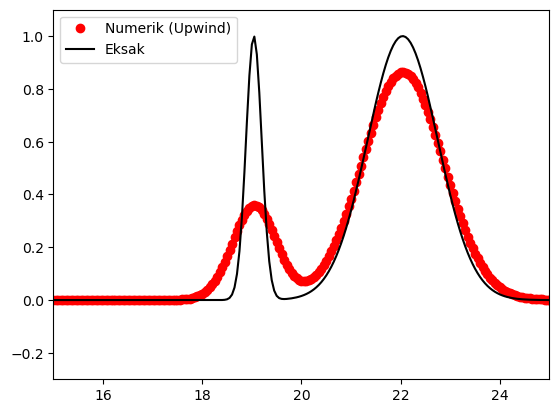

In [3]:
# Import library yang dibutuhkan
import numpy
import matplotlib.pyplot as plt

# Fungsi solusi eksak (true solution)
# Digunakan sebagai pembanding hasil numerik
u_true = lambda x, t: numpy.exp(-20.0 * ((x - t) - 2.0)**2) + numpy.exp(-((x - t) - 5.0)**2)

# Jumlah grid (banyak titik ruang)
m = 501

# Membuat domain ruang dari 0 sampai 25
x = numpy.linspace(0, 25.0, m)

# Menghitung jarak antar grid (Δx)
delta_x = 25.0 / (m - 1)

# CFL number (menentukan kestabilan metode)
cfl = 0.8

# Menghitung langkah waktu (Δt)
delta_t = cfl * delta_x

# Inisialisasi kondisi awal (t = 0)
U = u_true(x, 0)

# Menyediakan array untuk solusi di waktu berikutnya
U_new = numpy.empty(U.shape)

# Waktu awal
t = 0.0

# Waktu akhir simulasi
t_final = 17.0


# ----------------- LOOP UTAMA (UPWIND METHOD) -----------------
while t < t_final:
    
    # Boundary kiri (periodik)
    # Menggunakan titik terakhir sebagai tetangga kiri
    U_new[0] = U[0] - delta_t / delta_x * (U[0] - U[-1])
    
    # Perhitungan untuk semua titik lainnya (vectorized)
    # Menggunakan beda hingga satu arah (upwind)
    U_new[1:] = U[1:] - delta_t / delta_x * (U[1:] - U[:-1])
    
    # Catatan:
    # Baris berikut sebenarnya versi manual (tidak vectorized)
    # U_new[1:-1] = U[1:-1] - delta_t / delta_x * (U[1:-1] - U[:-2])
    # U_new[-1] = U[-1] - delta_t / delta_x * (U[-1] - U[-2])
    
    # Update solusi ke waktu berikutnya
    U = U_new.copy()
    
    # Update waktu
    t += delta_t


# ----------------- VISUALISASI -----------------

# Membuat figure
fig = plt.figure()

# Membuat axis
axes = fig.add_subplot(1, 1, 1)

# Plot hasil numerik (titik merah)
axes.plot(x, U, 'ro', label='Numerik (Upwind)')

# Plot solusi eksak (garis hitam)
axes.plot(x, u_true(x, t), 'k', label='Eksak')

# Mengatur batas tampilan sumbu x
axes.set_xlim((15.0, 25.0))

# Mengatur batas tampilan sumbu y
axes.set_ylim((-0.3, 1.1))

# Menambahkan legenda
axes.legend()

# Menampilkan grafik
plt.show()

### Stability
Sekarang kita akan melihat kestabilan dari metode upwind ini.

Untuk kasus $a > 0$, metode upwind dapat ditulis ulang sebagai:

$$
U^{n+1}_j = U^n_j - \frac{a \Delta t}{2 \Delta x} (U^n_j - U^n_{j-1}) + \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - 2U^n_j + U^n_{j-1})
$$

Bentuk ini menunjukkan bahwa metode upwind sebenarnya dapat dipandang sebagai kombinasi dari skema adveksi dan tambahan efek difusi numerik.

Dari sini, dapat dilihat bahwa nilai difusi efektifnya adalah $\epsilon = \frac{a \Delta x}{2}$.

Dari analisis *method of lines*, kita tahu bahwa metode seperti ini akan stabil jika memenuhi syarat berikut:

$$
\left |\frac{a \Delta t}{\Delta x} \right | \leq 1
$$

dan juga:

$$
-2 < -\frac{2 \epsilon \Delta t}{\Delta x^2} < 0.
$$

Artinya, metode akan tetap stabil jika rasio antara kecepatan adveksi, langkah waktu, dan langkah ruang tidak terlalu besar, serta efek difusi numeriknya berada dalam rentang tertentu.

Jika syarat ini terpenuhi, maka perhitungan numerik tidak akan meledak (tidak divergen) dan solusi tetap terkendali.

Untuk metode Lax-Friedrichs, nilai $\epsilon$ tidak bergantung pada $a$. Sedangkan pada metode Lax-Wendroff, $\epsilon$ bergantung pada $a^2$, sehingga selalu bernilai positif. Karena itu, syarat kestabilan kedua bisa dipenuhi dengan memilih $\Delta t$ dan $\Delta x$ yang sesuai.

Namun, pada metode upwind hal ini tidak selalu berlaku. Karena $\epsilon$ bergantung pada tanda $a$, maka $\epsilon$ bisa menjadi negatif.

Hal ini menghasilkan kondisi penting: bentuk metode upwind yang digunakan harus disesuaikan dengan tanda dari $a$ (apakah positif atau negatif), agar metode tetap stabil.

Untuk metode yang sedang kita bahas, syarat kestabilannya adalah:

$$
-2 < -\frac{2 \epsilon \Delta t}{\Delta x^2} < 0 \quad \Rightarrow \quad 0 \leq \frac{a \Delta t}{\Delta x} \leq 1
$$

Artinya, metode ini akan stabil jika nilai $\frac{a \Delta t}{\Delta x}$ berada di antara 0 dan 1.

Kita juga tahu bahwa batas atas dari syarat ini akan terpenuhi dengan baik jika $a > 0$.

Untuk metode yang melihat ke arah kanan, syarat kestabilannya adalah:

$$
-2 < -\frac{2 \epsilon \Delta t}{\Delta x^2} < 0 \quad \Rightarrow \quad -1 \leq \frac{a \Delta t}{\Delta x} \leq 0.
$$

Artinya, metode ini akan stabil jika nilai $\frac{a \Delta t}{\Delta x}$ berada di antara -1 dan 0.

Ini sesuai dengan kasus ketika arah aliran (ditentukan oleh tanda $a$) bergerak ke arah berlawanan, sehingga skema harus disesuaikan dengan arah tersebut.

Kita juga bisa memplot nilai eigen dari matriks untuk melihat bagaimana perilakunya pada setiap kasus.

Jika kita hubungkan kembali nilai $\epsilon$ untuk skema Lax-Friedrichs, Lax-Wendroff, dan upwind, maka diperoleh:

$$
\epsilon_{LW} = \frac{a^2 \Delta t}{2} = \frac{a \Delta x \nu}{2}, \quad
\epsilon_{UP} = \frac{a \Delta x}{2}, \quad
\epsilon_{LF} = \frac{\Delta x^2}{2 \Delta t} = \frac{a \Delta x}{2 \nu}
$$

dengan $\nu = \frac{a \Delta t}{\Delta x}$ yang disebut sebagai bilangan Courant.

Dari sini terlihat hubungan:

$$
\epsilon_{LW} = \nu \epsilon_{UP}, \quad \text{dan} \quad \epsilon_{UP} = \nu \epsilon_{LF}
$$

Jika $0 < \nu < 1$, maka berlaku urutan:

$$
\epsilon_{LW} < \epsilon_{UP} < \epsilon_{LF}
$$

Artinya, metode Lax-Wendroff dan Lax-Friedrichs menjadi batas bawah dan batas atas dari nilai $\epsilon$ yang masih stabil, sedangkan metode upwind berada di antara keduanya.

<>:70: SyntaxWarning: invalid escape sequence '\e'
<>:70: SyntaxWarning: invalid escape sequence '\e'
C:\Users\x260\AppData\Local\Temp\ipykernel_22816\1415312225.py:70: SyntaxWarning: invalid escape sequence '\e'
  axes.set_title("$\epsilon$ = %s, %s" % (epsilon, titles[i]))


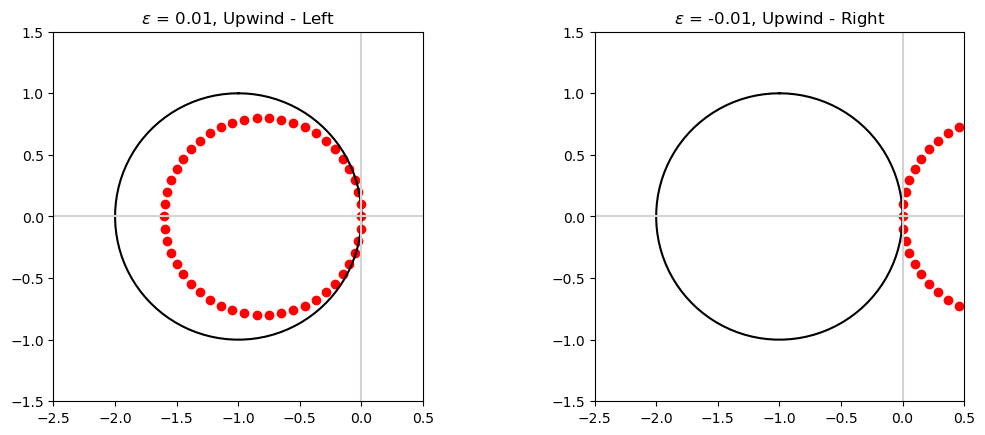

In [4]:
# Plot eigenvalues of the matrix A_ε and plot relative absolute stability region

def construct_A(epsilon, a=1.0, delta_x=0.02):
    """Membangun matriks A_ε (operator diskret untuk PDE adveksi)
    yang digunakan untuk menghitung nilai eigen (stabilitas metode)."""
    
    e = numpy.ones(int(1.0 / delta_x))  
    # Membuat vektor satuan sepanjang grid (jumlah titik ruang)

    A = numpy.diag(e[1:], 1) - numpy.diag(e[1:], -1)
    # Matriks turunan pertama (skema beda hingga pusat)

    A[0, -1] = -1
    A[-1, 0] = 1
    # Menambahkan kondisi batas periodik untuk turunan pertama

    B = numpy.diag(-2.0 * e, 0) + numpy.diag(e[1:], 1) + numpy.diag(e[1:], -1)
    # Matriks turunan kedua (Laplace/dispersi/difusi)

    B[0, -1] = 1
    B[-1, 0] = 1
    # Kondisi batas periodik untuk turunan kedua

    return -a / (2.0 * delta_x) * A + epsilon / delta_x**2 * B
    # Menggabungkan adveksi (A) dan difusi numerik (B)
    # menjadi operator diskret lengkap A_ε


delta_x = 0.02
# ukuran grid ruang

delta_t = 0.8 * delta_x
# langkah waktu (ditentukan oleh CFL condition)

a = 1.0
# kecepatan propagasi gelombang

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
# membuat figure lebih lebar untuk 2 plot

titles = ["Upwind - Left", "Upwind - Right"]
# judul untuk dua kasus skema upwind

for (i, epsilon) in enumerate((a * delta_x / 2.0, -a * delta_x / 2.0)):
    # loop untuk dua kasus:
    # 1. upwind kiri (a > 0)
    # 2. upwind kanan (a < 0)

    axes = fig.add_subplot(1, 2, i + 1, aspect='equal')
    # membuat subplot 1x2

    # Plot eigenvalues
    eigenvalues = numpy.linalg.eigvals(construct_A(epsilon, a, delta_x))
    # menghitung nilai eigen dari matriks operator diskret

    axes.plot(delta_t * eigenvalues.real, delta_t * eigenvalues.imag, 'ro')
    # memplot eigenvalues di bidang kompleks (scaled oleh Δt)
    # untuk analisis stabilitas numerik

    # Plot offset circle (daerah stabilitas absolut)
    theta = numpy.linspace(0.0, 2.0 * numpy.pi, 100)
    axes.plot(numpy.sin(theta) - 1.0, numpy.cos(theta), 'k')
    # lingkaran ini menunjukkan batas stabilitas metode time-stepping

    axes.set_xlim((-2.5, 0.5))
    axes.set_ylim((-1.5, 1.5))
    # batas tampilan grafik

    axes.set_title("$\epsilon$ = %s, %s" % (epsilon, titles[i]))
    # memberi judul sesuai nilai epsilon dan jenis upwind

    axes.plot([-2.5, 0.5], [0.0, 0.0], color='lightgray')
    axes.plot([0.0, 0.0], [-1.5, 1.5], color='lightgray')
    # garis sumbu real dan imajiner untuk referensi

plt.show()
# menampilkan grafik akhir

### Beam-Warming Method
Mungkin kamu sempat merasa aneh karena kita kembali lagi ke metode orde satu. Namun sebenarnya tidak perlu khawatir, karena *Beam-Warming method* tetap merupakan metode orde dua yang tetap memakai pendekatan satu arah (one-sided).

Jika kita kembali ke ekspansi yang digunakan saat menurunkan metode Lax-Wendroff:

$$
u(x, t + \Delta t) = u(x,t) - a \Delta t\, u_x(x,t) + \frac{a^2 \Delta t^2}{2} u_{xx}(x,t) + \frac{a^3 \Delta t^3}{6} u_{xxx}(x,t) + \mathcal{O}(\Delta t^4)
$$

lalu turunan-turunan ini kita aproksimasi menggunakan skema beda satu arah (bukan pusat), maka diperoleh:

### Untuk $a > 0$
$$
U^{n+1}_j = U^n_j - \frac{a \Delta t}{2 \Delta x} (3 U^n_j - 4 U^n_{j-1} + U^n_{j-2}) 
+ \frac{a^2 \Delta t^2}{2 \Delta x^2} (U^n_j - 2 U^n_{j-1} + U^n_{j-2})
$$

### Untuk $a < 0$
$$
U^{n+1}_j = U^n_j - \frac{a \Delta t}{2 \Delta x} (-3 U^n_j + 4 U^n_{j+1} - U^n_{j+2}) 
+ \frac{a^2 \Delta t^2}{2 \Delta x^2} (U^n_j - 2 U^n_{j+1} + U^n_{j+2})
$$

Metode ini dikatakan stabil jika:
- untuk $a > 0$: $0 \leq \nu \leq 2$
- untuk $a < 0$: $-2 \leq \nu \leq 0$

dengan $\nu = \frac{a \Delta t}{\Delta x}$ (bilangan Courant).

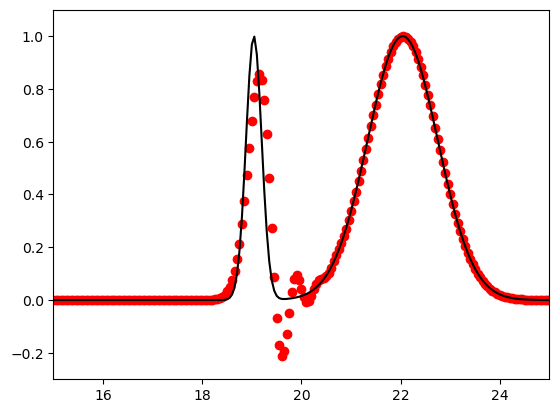

In [5]:
# Implement the Beam-Warming method for the PDE u_t + u_x = 0 on a periodic domain

u_true = lambda x, t: numpy.exp(-20.0 * ((x - t) - 2.0)**2) + numpy.exp(-((x - t) - 5.0)**2)
# Fungsi solusi eksak (true solution)
# Menggambarkan gelombang yang bergeser ke kanan seiring waktu

m = 501
# jumlah titik grid pada domain ruang

x = numpy.linspace(0, 25.0, m)
# membuat grid ruang dari 0 sampai 25

delta_x = 25.0 / (m - 1)
# ukuran langkah ruang (spasi antar titik grid)

cfl = 0.8
# angka Courant (CFL condition), menentukan kestabilan metode numerik

delta_t = cfl * delta_x
# langkah waktu berdasarkan CFL condition

U = u_true(x, 0)
# kondisi awal (initial condition) pada t = 0

U_new = numpy.empty(U.shape)
# array untuk menyimpan hasil update solusi di langkah waktu berikutnya

t = 0.0
# waktu awal simulasi

t_final = 17.0
# waktu akhir simulasi

while t < t_final:
    # loop waktu utama (time stepping loop)

    U_new[0] = U[0] - delta_t / (2.0 * delta_x) * (3.0 * U[0] - 4.0 * U[-1] + U[-2]) \
                + delta_t**2 / (2.0 * delta_x**2) * (U[0] - 2.0 * U[-1] + U[-2])
    # update titik pertama (boundary kiri) dengan Beam-Warming scheme
    # menggunakan periodic boundary (U[-1], U[-2])

    U_new[1] = U[1] - delta_t / (2.0 * delta_x) * (3.0 * U[1] - 4.0 * U[0] + U[-1]) \
                + delta_t**2 / (2.0 * delta_x**2) * (U[1] - 2.0 * U[0] + U[-1])
    # update titik kedua, masih memakai skema satu arah (upwind kanan)

    U_new[2:] = U[2:] - delta_t / (2.0 * delta_x) * (3.0 * U[2:] - 4.0 * U[1:-1] + U[:-2]) \
                      + delta_t**2 / (2.0 * delta_x**2) * (U[2:] - 2.0 * U[1:-1] + U[:-2])
    # update seluruh titik interior dengan skema Beam-Warming orde 2
    # menggunakan informasi dari titik sebelumnya (upwind stencil)

    U = U_new.copy()
    # memperbarui solusi untuk langkah waktu berikutnya

    t += delta_t
    # menambah waktu simulasi


# ===================== PLOTTING =====================

fig = plt.figure()
# membuat figure baru untuk grafik

axes = fig.add_subplot(1, 1, 1)
# membuat satu plot utama

axes.plot(x, U, 'ro')
# hasil numerik (Beam-Warming) pada t akhir

axes.plot(x, u_true(x, t), 'k')
# solusi eksak pada waktu t yang sama

axes.set_xlim((15.0, 25.0))
# batas tampilan sumbu x

axes.set_ylim((-0.3, 1.1))
# batas tampilan sumbu y

plt.show()
# menampilkan grafik

## Von Neumann Analysis
Sekarang kita mencoba menurunkan syarat kestabilan yang mirip seperti pada metode *method of lines*, tetapi kali ini menggunakan analisis von Neumann.

Ingat kembali bahwa pada analisis von Neumann, kita mengganti solusi diskret $U^n_j$ dengan bentuk:

$$
U^n_j = g(\xi)^n e^{i \xi j \Delta x}
$$

Kemudian kita mencari bentuk dari faktor penguat (*amplification factor*) $g(\xi)$.

Jika nilai faktor penguat memenuhi:

$$
|g(\xi)| \leq 1
$$

maka metode numerik tersebut dikatakan stabil.

Pada bagian ini kita juga memperkenalkan notasi baru:

$$
\nu \equiv \frac{a \Delta t}{\Delta x}
$$

yang disebut sebagai bilangan Courant, dan akan sering digunakan pada pembahasan selanjutnya.

### Example - Upwind
Metode upwind untuk kasus $a > 0$ diberikan oleh:

$$
U^{n+1}_j = U^n_j - \frac{a \Delta t}{\Delta x}(U^n_{j} - U^n_{j - 1}).
$$

Tugasnya adalah menurunkan faktor amplifikasi (*amplification factor*) dari skema ini, lalu menentukan syarat kestabilan metode tersebut.

Jika kita substitusikan solusi gelombang bidang (*plane-wave*) ke dalam skema, diperoleh:

$$
\begin{aligned}
g(\xi) &= 1 - \frac{a \Delta t}{\Delta x} (1 - e^{-i \xi \Delta x}) \\
&= (1 - \nu) + \nu e^{-i \xi \Delta x}.
\end{aligned}
$$

Faktor amplifikasi $g(\xi)$ ini berubah terhadap bilangan gelombang $\xi$, dan secara geometris membentuk sebuah lintasan berupa lingkaran dengan jari-jari $\nu$ dan pusat di titik $1 - \nu$.

Perhatikan bahwa jika $\nu = 1$, maka lingkaran tersebut berpusat di origin dan memiliki jari-jari 1 (lingkaran satuan). Artinya, skema berada tepat di batas kestabilan.

Sedangkan jika $\nu = 0$, kasus ini tidak terlalu menarik karena berarti $a = 0$, sehingga tidak ada proses adveksi (kasus trivial).

Kesimpulannya, agar metode upwind stabil, harus berlaku:

$$
0 \leq \nu \leq 1.
$$

Untuk kasus $a < 0$, kondisi stabilitasnya menjadi:

$$
-1 \leq \nu \leq 0.
$$

### Example - Lax-Wendroff
Turunkan faktor amplifikasi (*amplification factor*) untuk metode Lax-Wendroff berikut:

$$
U^{n+1}_j = U^n_j - \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1})
+ \frac{a^2 \Delta t^2}{2 \Delta x^2} (U^n_{j+1} - 2 U^n_{j} + U^n_{j-1})
$$

Artinya, kita diminta mencari bentuk faktor penguat $g(\xi)$ dari skema ini menggunakan analisis Fourier (von Neumann), lalu menyederhanakan hasilnya.

Berikut adalah hasil perhitungan faktor amplifikasi (*amplification factor*) untuk metode Lax-Wendroff:

$$
\begin{aligned}
g(\xi) &= 1 - \frac{\nu}{2} \left(e^{i \xi \Delta x} - e^{-i \xi \Delta x} \right )
+ \frac{\nu^2}{2} \left (e^{i \xi \Delta x} - 2 + e^{-i \xi \Delta x} \right ) \\
&= 1 - i \nu \sin(\xi \Delta x) + \nu^2 (\cos(\xi \Delta x) - 1)
\end{aligned}
$$

Bentuk ini kemudian dapat ditulis ulang menggunakan identitas trigonometri agar lebih mudah dihitung besar nilainya:

$$
g(\xi) = 1 - i \nu 2\sin\left(\frac{\xi \Delta x}{2}\right)\cos\left(\frac{\xi \Delta x}{2}\right)
- \nu^2 2\sin^2\left(\frac{\xi \Delta x}{2}\right)
$$

(Bentuk ini dipilih supaya lebih mudah saat menghitung nilai mutlaknya.)

Selanjutnya, kita hitung kuadrat modulusnya:

$$
\begin{aligned}
|g(\xi)|^2 &= \left(1 - 2\nu^2 \sin^2\left(\frac{\xi \Delta x}{2}\right)\right)^2
+ 4 \nu^2 \sin^2\left(\frac{\xi \Delta x}{2}\right)\cos^2\left(\frac{\xi \Delta x}{2}\right) \\
&= 1 + 4 \nu^2 \sin^2\left(\frac{\xi \Delta x}{2}\right)
\left(\cos^2\left(\frac{\xi \Delta x}{2}\right) - 1\right)
+ 4\nu^4 \sin^4\left(\frac{\xi \Delta x}{2}\right) \\
&= 1 - 4 \nu^2 (1 - \nu^2)\sin^4\left(\frac{\xi \Delta x}{2}\right)
\end{aligned}
$$

Karena untuk semua $\xi$ berlaku:

$$
0 \leq \sin^4\left(\frac{\xi \Delta x}{2}\right) \leq 1,
$$

maka agar metode ini stabil harus dipenuhi:

$$
|\nu| \leq 1.
$$

Artinya, metode Lax-Wendroff stabil jika bilangan Courant $\nu$ berada di antara -1 dan 1.

### Example - Lax-Friedrichs
Turunkan faktor amplifikasi (*amplification factor*) untuk metode Lax-Friedrichs berikut:

$$
U^{n+1}_j = \frac{1}{2}(U^n_{j-1} + U^n_{j+1}) - \frac{a \Delta t}{2 \Delta x} (U^n_{j+1} - U^n_{j-1}).
$$

Artinya, kita diminta mencari bentuk faktor penguat $g(\xi)$ dari skema ini menggunakan analisis Fourier (von Neumann), lalu menyederhanakan hasilnya untuk melihat sifat kestabilannya.

Berikut hasil perhitungan faktor amplifikasi (*amplification factor*) untuk metode Lax-Friedrichs:

$$
\begin{aligned}
g(\xi) &= \frac{1}{2} (e^{i \xi \Delta x} + e^{-i \xi \Delta x})
- \frac{\nu}{2} (e^{i \xi \Delta x} - e^{-i \xi \Delta x}) \\
&= \cos(\xi \Delta x) - i \nu \sin(\xi \Delta x)
\end{aligned}
$$

Dari bentuk ini, kita dapat menghitung besar kuadratnya:

$$
|g(\xi)|^2 = \cos^2(\xi \Delta x) + \nu^2 \sin^2(\xi \Delta x)
$$

Agar metode tetap stabil (tidak terjadi pertumbuhan error), harus dipenuhi syarat:

$$
|\nu| \leq 1.
$$

Artinya, metode Lax-Friedrichs hanya stabil jika bilangan Courant $\nu$ berada di antara -1 dan 1.

### Example - Leapfrog
Soal ini sedikit lebih menantang, tetapi masih bisa dikerjakan.

Kita diminta untuk menurunkan faktor amplifikasi (*amplification factor*) serta kriteria kestabilan untuk metode *leapfrog* berikut:

$$
U^{n+1}_j = U^{n-1}_j - \frac{a \Delta t}{\Delta x} (U^n_{j+1} - U^n_{j-1})
$$

Artinya, kita perlu menganalisis skema ini menggunakan metode Fourier (von Neumann) untuk mengetahui bagaimana error berkembang dan kondisi apa yang membuat metode ini tetap stabil.

Dari analisis ini diperoleh hubungan:

$$
\begin{aligned}
g(\xi)^2 &= 1 - \nu g(\xi)\left(e^{i \xi \Delta x} - e^{-i \xi \Delta x}\right) \\
&= 1 - 2\nu i \sin(\xi \Delta x)\, g(\xi).
\end{aligned}
$$

Persamaan ini menghasilkan dua kemungkinan (dua cabang) untuk nilai $g(\xi)$:

$$
g_{1,2}(\xi) = -\nu i \sin(\xi \Delta x) \pm \sqrt{1 - \nu^2 \sin^2(\xi \Delta x)}.
$$

Selanjutnya, besar kuadratnya dapat ditulis sebagai:

$$
|g_{1,2}(\xi)|^2 = \nu^2 \sin^2(\xi \Delta x) + \left(1 - \nu^2 \sin^2(\xi \Delta x)\right)
$$

yang menyederhana menjadi nilai yang selalu ≤ 1, selama:

$$
|\nu| \leq 1.
$$

Artinya, metode leapfrog akan stabil jika bilangan Courant $\nu$ berada dalam rentang -1 hingga 1.